In [1]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 22.2 MB/s eta 0:00:00


In [2]:
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import scipy.stats as stats
from scipy.stats import skew, kurtosis

import warnings
warnings.simplefilter('ignore')

In [3]:
df = pd.read_csv("/kaggle/input/time-series-of-industrial-boiler-operations/data_AutoReg.csv", parse_dates=["date"]) 
df.set_index("date", inplace=True)

furnace_pressure = df["PT_8313A.AV_0#"].dropna() # Upper furnace pressure (A)
steam_flow_rate = df["ZZQBCHLL.AV_0#"].dropna() # Main steam flow rate after compensation
vibration = df["YFJ3_ZD1.AV_0#"].dropna() # Vibration of induced draft fan bearing shell (A)  
outlet_temp = df["TE_8332A.AV_0#"].dropna() # Boiler outlet steam temperature

## Exploratory Data Analysis (EDA)

In this section, we conduct a comprehensive exploratory data analysis (EDA) of four critical time series variables from a coal-fired industrial boiler. These include:

- Upper furnace pressure (A)

- Main steam flow rate (after compensation)

- Vibration of the induced draft fan bearing shell (A)

- Boiler outlet steam temperature

We will use line plots, histograms, boxplots, and Q-Q plots to explore both the distributional and temporal characteristics of these variables.

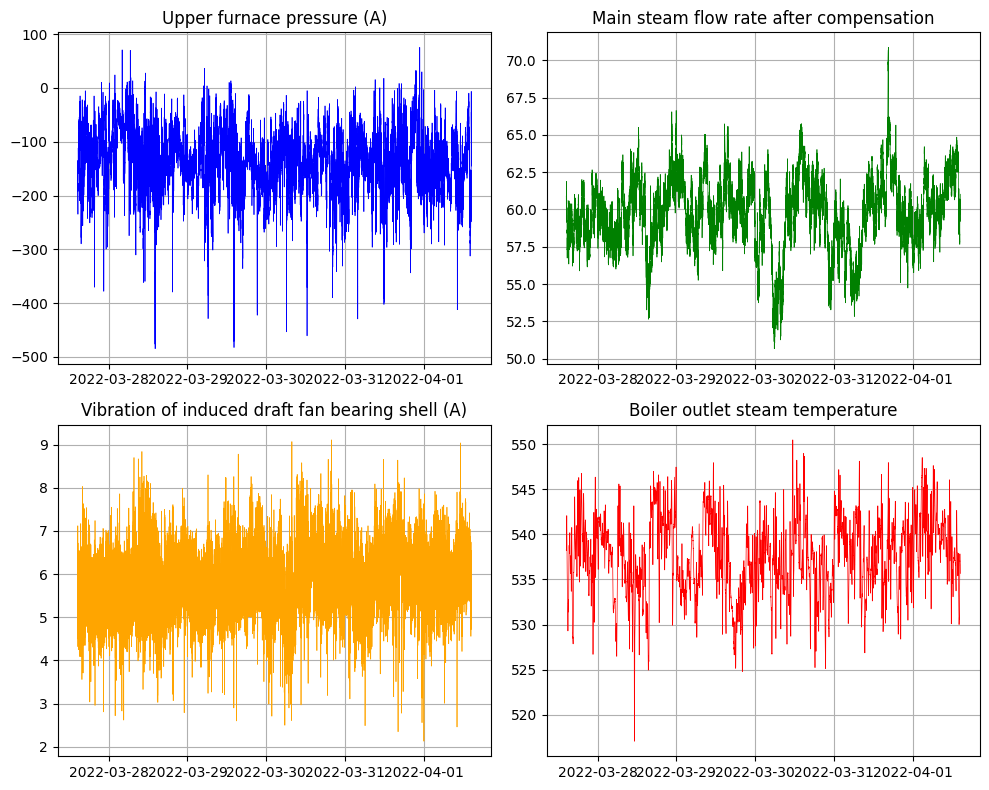

In [4]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0, 0].plot(furnace_pressure, color='blue', linewidth=0.5)
axs[0, 0].set_title('Upper furnace pressure (A)')
axs[0, 0].grid(True)

axs[0, 1].plot(steam_flow_rate, color='green', linewidth=0.5)
axs[0, 1].set_title('Main steam flow rate after compensation')
axs[0, 1].grid(True)

axs[1, 0].plot(vibration, color='orange', linewidth=0.5)
axs[1, 0].set_title('Vibration of induced draft fan bearing shell (A)')
axs[1, 0].grid(True)

axs[1, 1].plot(outlet_temp, color='red', linewidth=0.5)
axs[1, 1].set_title('Boiler outlet steam temperature')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()


What to Look For:
- Identify visible trends, seasonality, or abrupt shifts.

- Look for sudden spikes, drops, or recurring patterns which may indicate anomalies or process changes.

Theoretical Note:
Time series plots provide direct insight into the temporal structure and stability of a process. Stationarity, seasonality, and noise characteristics can be preliminarily assessed visually.

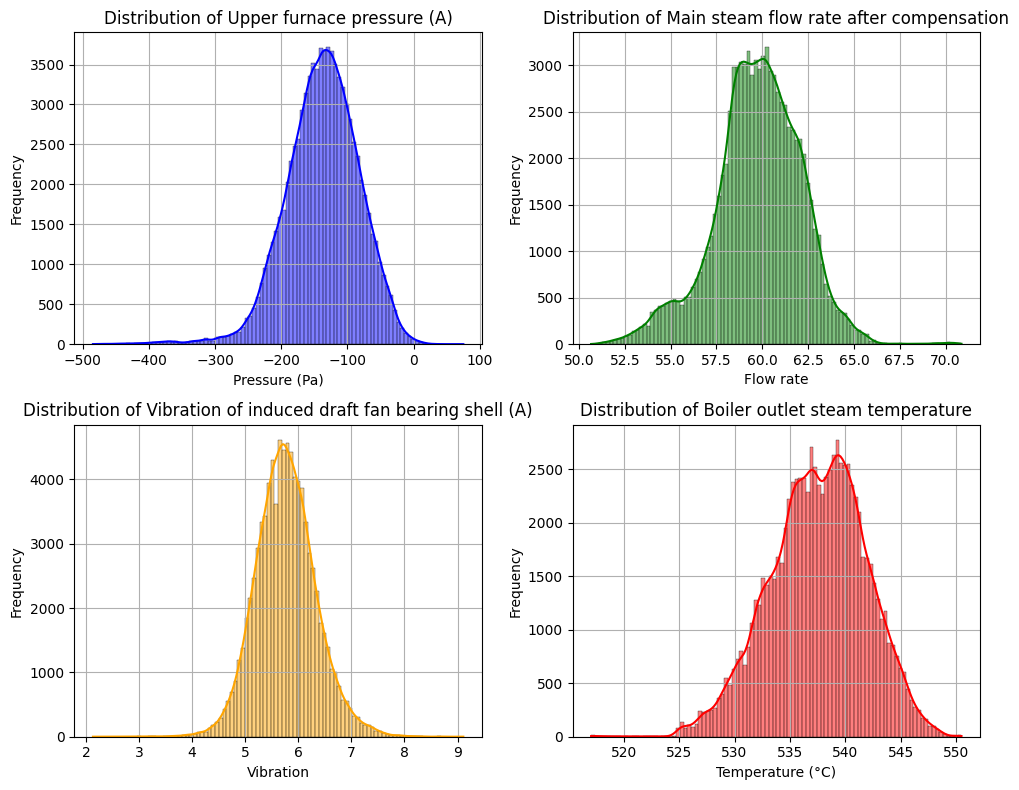

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

sns.histplot(furnace_pressure, color='blue', bins=100, kde=True, ax=axs[0, 0])
axs[0, 0].set_xlabel("Pressure (Pa)")
axs[0, 0].set_ylabel("Frequency")
axs[0, 0].set_title('Distribution of Upper furnace pressure (A)')
axs[0, 0].grid(True)

sns.histplot(steam_flow_rate, color='green', bins=100, kde=True, ax=axs[0, 1])
axs[0, 1].set_xlabel("Flow rate")
axs[0, 1].set_ylabel("Frequency")
axs[0, 1].set_title('Distribution of Main steam flow rate after compensation')
axs[0, 1].grid(True)

sns.histplot(vibration, color='orange', bins=100, kde=True, ax=axs[1, 0])
axs[1, 0].set_xlabel("Vibration")
axs[1, 0].set_ylabel("Frequency")
axs[1, 0].set_title('Distribution of Vibration of induced draft fan bearing shell (A)')
axs[1, 0].grid(True)

sns.histplot(outlet_temp, color='red', bins=100, kde=True, ax=axs[1, 1])
axs[1, 1].set_xlabel("Temperature (°C)")
axs[1, 1].set_ylabel("Frequency")
axs[1, 1].set_title('Distribution of Boiler outlet steam temperature')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()


Theoretical Note:
Histograms show the empirical distribution of a variable, while Kernel Density Estimation (KDE) approximates its probability density function. This is useful for:

- Checking for skewness, modality (e.g., uni- or bimodal), and outlier-prone tails.

- Evaluating normality or heavy-tailed behavior.

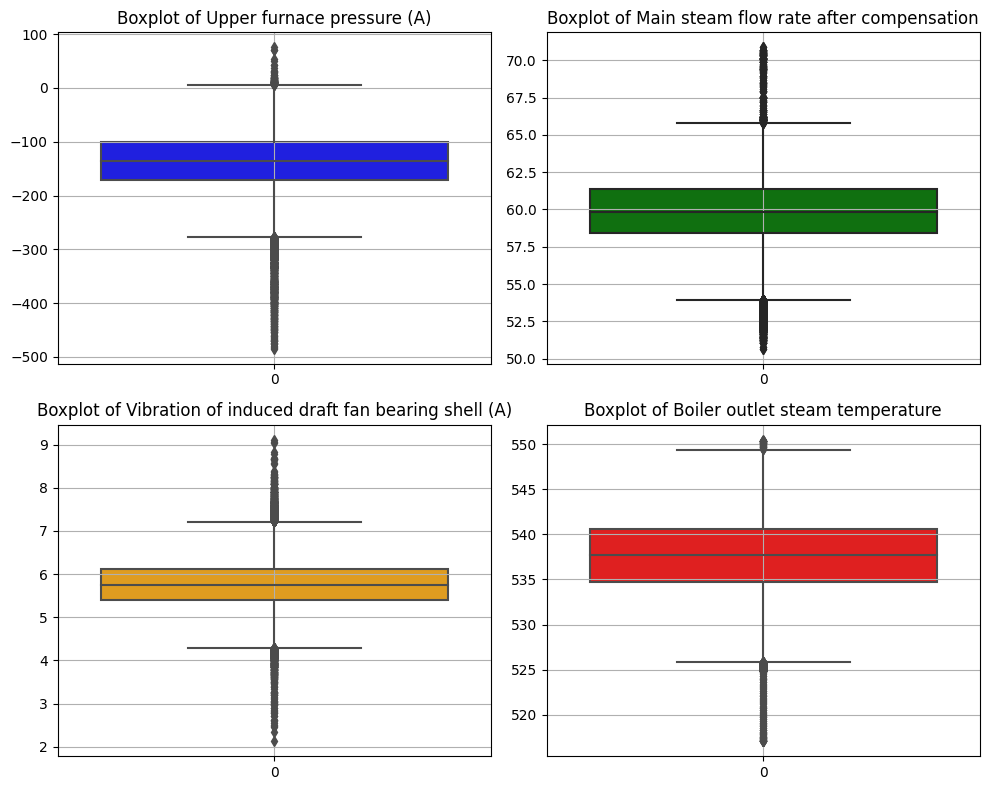

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

sns.boxplot(furnace_pressure, color='blue', ax=axs[0, 0])
axs[0, 0].set_title('Boxplot of Upper furnace pressure (A)')
axs[0, 0].grid(True)

sns.boxplot(steam_flow_rate, color='green', ax=axs[0, 1])
axs[0, 1].set_title('Boxplot of Main steam flow rate after compensation')
axs[0, 1].grid(True)

sns.boxplot(vibration, color='orange', ax=axs[1, 0])
axs[1, 0].set_title('Boxplot of Vibration of induced draft fan bearing shell (A)')
axs[1, 0].grid(True)

sns.boxplot(outlet_temp, color='red', ax=axs[1, 1])
axs[1, 1].set_title('Boxplot of Boiler outlet steam temperature')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()


What to Look For:
- Median, interquartile range (IQR), and outliers.

- Identify potential process anomalies or sensor noise (especially if outliers are frequent or extreme).

Theoretical Note:
Boxplots are robust summary tools for identifying asymmetry and outliers. In time series, persistent outliers may indicate:

- Faulty sensor readings.

- Process instability.

- Transient events such as pressure drops or surges.

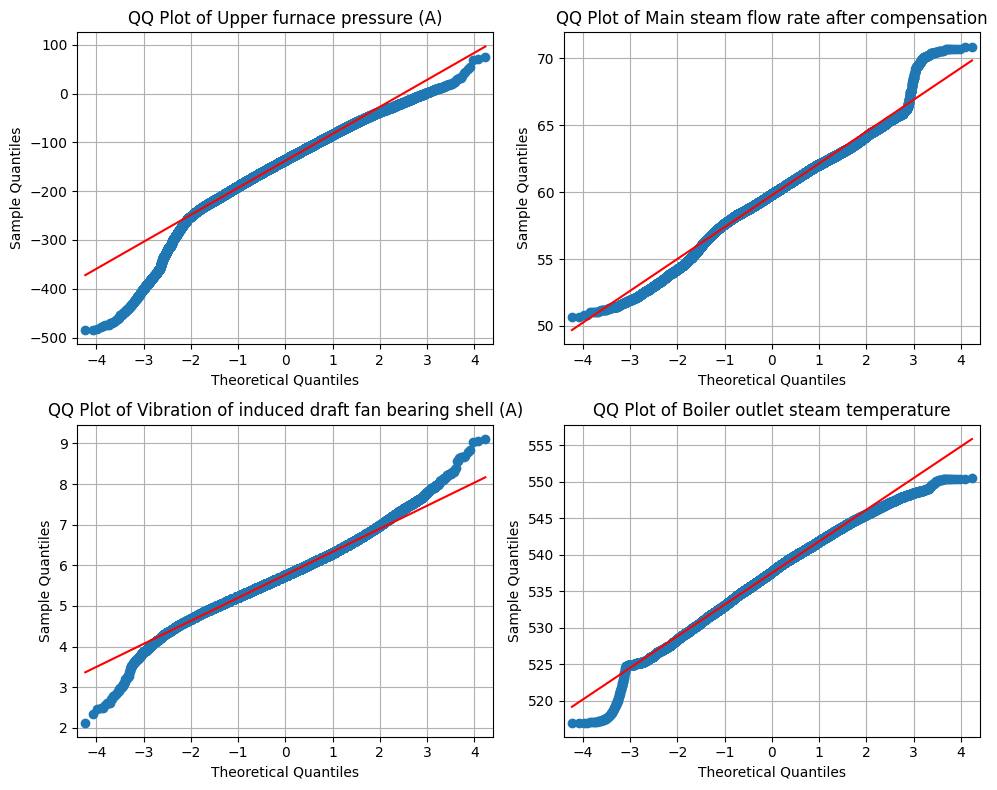

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

sm.qqplot(furnace_pressure, color='blue', ax=axs[0, 0], line='s')
axs[0, 0].set_title('QQ Plot of Upper furnace pressure (A)')
axs[0, 0].grid(True)

sm.qqplot(steam_flow_rate, color='green', ax=axs[0, 1], line='s')
axs[0, 1].set_title('QQ Plot of Main steam flow rate after compensation')
axs[0, 1].grid(True)

sm.qqplot(vibration, color='orange', ax=axs[1, 0], line='s')
axs[1, 0].set_title('QQ Plot of Vibration of induced draft fan bearing shell (A)')
axs[1, 0].grid(True)

sm.qqplot(outlet_temp, color='red', ax=axs[1, 1], line='s')
axs[1, 1].set_title('QQ Plot of Boiler outlet steam temperature')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

What to Look For:
- Close alignment to the diagonal line suggests approximate normality.

- S-shaped curves indicate skewness.

- Heavy tails appear as curvature at ends.

Theoretical Note:
A Q-Q plot (quantile-quantile plot) compares the quantiles of a dataset to a theoretical normal distribution. This is crucial in determining if statistical modeling assumptions like normality are valid, especially before applying methods like ARIMA or control charts.



## Rolling Mean and Standard Deviation Analysis

### Purpose

This section visualizes the **rolling (moving) mean** and **rolling standard deviation** for key process variables from a coal-fired boiler system. These statistics are essential for analyzing the **local trends** and **volatility** of the time series data.

---

### What This Code Does

We compute **rolling statistics** with a fixed window size of `50` for the following variables:

* `furnace_pressure`: Upper furnace pressure (A)
* `steam_flow_rate`: Main steam flow rate after compensation
* `vibration`: Vibration of the induced draft fan bearing shell (A)
* `outlet_temp`: Boiler outlet steam temperature

For each variable, we compute:

* **Rolling Mean**: A local average of the time series values, useful for trend smoothing.
* **Rolling Standard Deviation**: A measure of local variability or fluctuation around the mean.

---

### Theoretical Background

#### Rolling Mean (Moving Average)

The **rolling mean** with window size $w$ for a time series $x_t$ is defined as:

$$
\text{RollingMean}_t = \frac{1}{w} \sum_{i=0}^{w-1} x_{t-i}
$$

It smooths out short-term fluctuations and highlights long-term trends or cycles.

#### Rolling Standard Deviation

The **rolling standard deviation** estimates local volatility in the series:

$$
\text{RollingStd}_t = \sqrt{ \frac{1}{w} \sum_{i=0}^{w-1} (x_{t-i} - \bar{x}_t)^2 }
$$

High rolling standard deviation values indicate greater local variability, which could signal instability or anomalies in the system.

---

### Visualization Structure

The figure is organized as follows:

| Row | Left Column (Rolling Mean)  | Right Column (Rolling Std Dev)    |
| --- | --------------------------- | --------------------------------- |
| 1   | Upper furnace pressure      | Std Dev of Upper furnace pressure |
| 2   | Main steam flow rate        | Std Dev of Main steam flow rate   |
| 3   | Fan bearing shell vibration | Std Dev of vibration              |
| 4   | Boiler outlet temperature   | Std Dev of outlet temperature     |

* The **left column** shows the raw time series with the overlaid rolling mean.
* The **right column** shows the rolling standard deviation.

---

### Interpretation Tips

* **Stable Systems**: A stable process should have relatively low and constant rolling standard deviation.
* **Trends**: Rolling mean helps detect trends like increasing temperature or decreasing pressure.
* **Anomalies**: Sudden spikes in standard deviation might indicate faults, operational changes, or sensor issues.

---

### Why This Is Important

* Rolling statistics are fundamental for **stationarity checks**, which are prerequisites for many time series models (e.g., ARIMA).
* They help detect **non-obvious patterns**, **drift**, or **shifts** in the process behavior over time.
* Rolling std is useful for **early anomaly detection** in industrial systems.


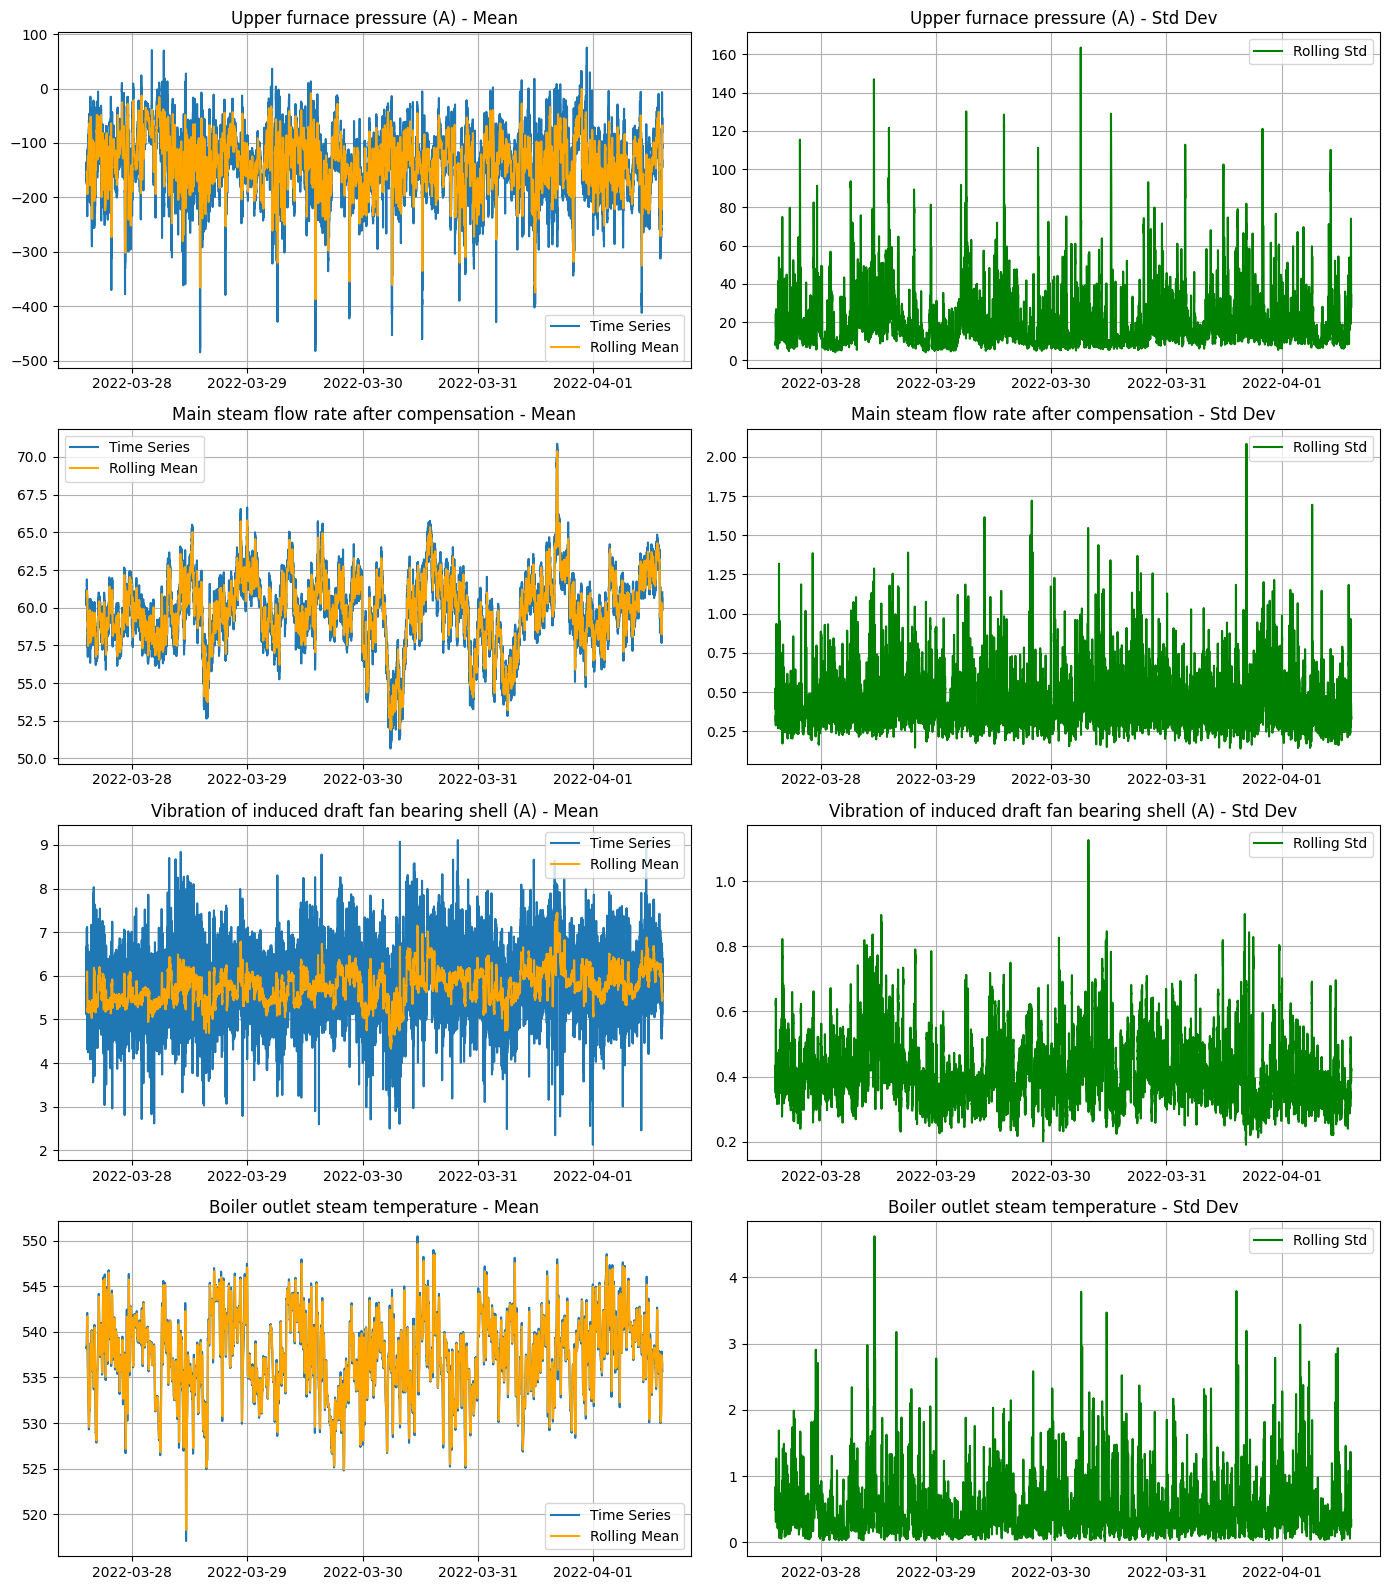

In [8]:
window_size = 50

furnace_pressure_rolling_mean = furnace_pressure.rolling(window=window_size).mean()
furnace_pressure_rolling_std = furnace_pressure.rolling(window=window_size).std()

steam_flow_rate_rolling_mean = steam_flow_rate.rolling(window=window_size).mean()
steam_flow_rate_rolling_std = steam_flow_rate.rolling(window=window_size).std()

vibration_rolling_mean = vibration.rolling(window=window_size).mean()
vibration_rolling_std = vibration.rolling(window=window_size).std()

outlet_temp_rolling_mean = outlet_temp.rolling(window=window_size).mean()
outlet_temp_rolling_std = outlet_temp.rolling(window=window_size).std()

fig, axs = plt.subplots(4, 2, figsize=(14, 16))

axs[0, 0].plot(furnace_pressure, label='Time Series')
axs[0, 0].plot(furnace_pressure_rolling_mean, label='Rolling Mean', color='orange')
axs[0, 0].set_title('Upper furnace pressure (A) - Mean')
axs[0, 0].legend()
axs[0, 0].grid(True)

axs[1, 0].plot(steam_flow_rate, label='Time Series')
axs[1, 0].plot(steam_flow_rate_rolling_mean, label='Rolling Mean', color='orange')
axs[1, 0].set_title('Main steam flow rate after compensation - Mean')
axs[1, 0].legend()
axs[1, 0].grid(True)

axs[2, 0].plot(vibration, label='Time Series')
axs[2, 0].plot(vibration_rolling_mean, label='Rolling Mean', color='orange')
axs[2, 0].set_title('Vibration of induced draft fan bearing shell (A) - Mean')
axs[2, 0].legend()
axs[2, 0].grid(True)

axs[3, 0].plot(outlet_temp, label='Time Series')
axs[3, 0].plot(outlet_temp_rolling_mean, label='Rolling Mean', color='orange')
axs[3, 0].set_title('Boiler outlet steam temperature - Mean')
axs[3, 0].legend()
axs[3, 0].grid(True)

axs[0, 1].plot(furnace_pressure_rolling_std, label='Rolling Std', color='green')
axs[0, 1].set_title('Upper furnace pressure (A) - Std Dev')
axs[0, 1].legend()
axs[0, 1].grid(True)

axs[1, 1].plot(steam_flow_rate_rolling_std, label='Rolling Std', color='green')
axs[1, 1].set_title('Main steam flow rate after compensation - Std Dev')
axs[1, 1].legend()
axs[1, 1].grid(True)

axs[2, 1].plot(vibration_rolling_std, label='Rolling Std', color='green')
axs[2, 1].set_title('Vibration of induced draft fan bearing shell (A) - Std Dev')
axs[2, 1].legend()
axs[2, 1].grid(True)

axs[3, 1].plot(outlet_temp_rolling_std, label='Rolling Std', color='green')
axs[3, 1].set_title('Boiler outlet steam temperature - Std Dev')
axs[3, 1].legend()
axs[3, 1].grid(True)

plt.tight_layout()
plt.show()


## Statistical Summary and Stationarity Tests

### Purpose

This section performs **descriptive statistical analysis** and **stationarity testing** for four key time series variables from an industrial boiler system:

* Furnace Pressure
* Steam Flow Rate
* Vibration
* Outlet Steam Temperature

This step is critical before applying time series models such as **ARIMA**, **SARIMA**, or other forecasting tools that assume stationarity.

---

### Theoretical Background

#### Skewness

Skewness quantifies the **asymmetry** of a distribution:

* $\text{Skewness} > 0$: Right-tailed (positively skewed)
* $\text{Skewness} < 0$: Left-tailed (negatively skewed)
* $\text{Skewness} = 0$: Symmetrical

#### Kurtosis

Kurtosis measures the **"tailedness"** of a distribution:

* $\text{Kurtosis} > 3$: Leptokurtic (heavy tails)
* $\text{Kurtosis} < 3$: Platykurtic (light tails)
* $\text{Kurtosis} = 3$: Normal (mesokurtic)

Note: In this code, **Fisher’s definition** is used (i.e., 0 = normal distribution).

---

### Stationarity Tests

Stationarity implies that the **mean, variance, and autocovariance** of the series are constant over time. This is a critical assumption for many time series models.

| Test                                         | Null Hypothesis                                    | Interpretation                                |
| -------------------------------------------- | -------------------------------------------------- | --------------------------------------------- |
| **ADF (Augmented Dickey-Fuller)**            | The series is **non-stationary** (has a unit root) | *p-value < 0.05 → reject H₀ → stationary*     |
| **KPSS (Kwiatkowski–Phillips–Schmidt–Shin)** | The series is **stationary**                       | *p-value < 0.05 → reject H₀ → non-stationary* |

Thus, the two tests are **complementary**:

* If ADF rejects H₀ and KPSS does not → Strong evidence of stationarity.
* If both tests reject H₀ → Inconclusive; possibly trend-stationary.

To address non-stationarity, we also test the **first-differenced** series.

---


In [9]:
furnace_pressure_skewness = skew(furnace_pressure)
furnace_pressure_kurtosis = kurtosis(furnace_pressure)
furnace_pressure_ADF = adfuller(furnace_pressure)[1]
furnace_pressure_kpss = kpss(furnace_pressure, regression='c')[1]
steam_flow_rate_skewness = skew(steam_flow_rate)
steam_flow_rate_kurtosis = kurtosis(steam_flow_rate)
steam_flow_rate_ADF = adfuller(steam_flow_rate)[1]
steam_flow_rate_kpss = kpss(steam_flow_rate, regression='c')[1]
vibration_skewness =   skew(vibration)
vibration_kurtosis = kurtosis(vibration)
vibration_ADF = adfuller(vibration)[1]
vibration_kpss = kpss(vibration, regression='c')[1]
outlet_temp_skewness = skew(outlet_temp)
outlet_temp_kurtosis = kurtosis(outlet_temp)
outlet_temp_ADF = adfuller(outlet_temp)[1]
outlet_temp_kpss = kpss(outlet_temp, regression='c')[1]

furnace_pressure_diff_ADF = adfuller(furnace_pressure.diff().dropna())[1]
furnace_pressure_diff_kpss = kpss(furnace_pressure.diff().dropna(), regression='c')[1]

steam_flow_rate_diff_ADF = adfuller(steam_flow_rate.diff().dropna())[1]
steam_flow_rate_diff_kpss = kpss(steam_flow_rate.diff().dropna(), regression='c')[1]

vibration_diff_ADF = adfuller(vibration.diff().dropna())[1]
vibration_diff_kpss = kpss(vibration.diff().dropna(), regression='c')[1]

outlet_temp_diff_ADF = adfuller(outlet_temp.diff().dropna())[1]
outlet_temp_diff_kpss = kpss(outlet_temp.diff().dropna(), regression='c')[1]

result_df = pd.DataFrame({
    "Feature": [
        "Furnace Pressure",
        "Steam Flow Rate",
        "Vibration",
        "Outlet Temperature"
    ],
    "Skewness": [
        furnace_pressure_skewness,
        steam_flow_rate_skewness,
        vibration_skewness,
        outlet_temp_skewness
    ],
    "Kurtosis": [
        furnace_pressure_kurtosis,
        steam_flow_rate_kurtosis,
        vibration_kurtosis,
        outlet_temp_kurtosis
    ],
    "ADF (original)": [
        furnace_pressure_ADF,
        steam_flow_rate_ADF,
        vibration_ADF,
        outlet_temp_ADF
    ],
    "KPSS (original)": [
        furnace_pressure_kpss,
        steam_flow_rate_kpss,
        vibration_kpss,
        outlet_temp_kpss
    ],
    "ADF (diff)": [
        furnace_pressure_diff_ADF,
        steam_flow_rate_diff_ADF,
        vibration_diff_ADF,
        outlet_temp_diff_ADF
    ],
    "KPSS (diff)": [
        furnace_pressure_diff_kpss,
        steam_flow_rate_diff_kpss,
        vibration_diff_kpss,
        outlet_temp_diff_kpss
    ]
})

print(result_df)


              Feature  Skewness  Kurtosis  ADF (original)  KPSS (original)  \
0    Furnace Pressure -0.606940  1.753128    0.000000e+00             0.01   
1     Steam Flow Rate -0.287475  0.724693    9.005895e-14             0.01   
2           Vibration  0.173817  0.906210    1.998133e-26             0.01   
3  Outlet Temperature -0.246884 -0.042081    7.377972e-25             0.01   

   ADF (diff)  KPSS (diff)  
0         0.0          0.1  
1         0.0          0.1  
2         0.0          0.1  
3         0.0          0.1  



| Feature            | Skewness | Kurtosis | ADF (original) | KPSS (original) | ADF (diff) | KPSS (diff) |
| ------------------ | -------- | -------- | -------------- | --------------- | ---------- | ----------- |
| Furnace Pressure   | -0.61    | 1.75     | 0.00000        | 0.01            | 0.0        | 0.1         |
| Steam Flow Rate    | -0.29    | 0.72     | 9e-14          | 0.01            | 0.0        | 0.1         |
| Vibration          | 0.17     | 0.91     | 2e-26          | 0.01            | 0.0        | 0.1         |
| Outlet Temperature | -0.25    | -0.04    | 7e-25          | 0.01            | 0.0        | 0.1         |

---

### Interpretation

#### 1. **Skewness and Kurtosis**

* **Skewness** measures asymmetry of the data distribution:

  * Negative skewness (e.g., Furnace Pressure -0.61) indicates a left tail is longer or fatter.
  * Positive skewness (Vibration 0.17) indicates right tail is heavier.
  * Values close to zero (like Outlet Temperature -0.25) imply near symmetry.
* **Kurtosis** measures tail heaviness relative to a normal distribution:

  * Positive kurtosis (>0) means heavier tails and sharper peak than normal.
  * Negative kurtosis (<0) means lighter tails and flatter peak.
  * Here, most features have moderate kurtosis, suggesting some deviation from normality.

---

#### 2. **Stationarity Tests**

* **ADF (Augmented Dickey-Fuller) test**:

  * Null hypothesis (H₀): The series has a unit root (i.e., is non-stationary).
  * Small p-values (< 0.05) mean we reject H₀ → series is stationary.

* **KPSS (Kwiatkowski-Phillips-Schmidt-Shin) test**:

  * Null hypothesis (H₀): The series is stationary.
  * Small p-values (< 0.05) mean we reject H₀ → series is non-stationary.

---

### 3. **Results Explanation**

* For the **original series**:

  * ADF p-values are effectively zero → strong evidence for stationarity.
  * KPSS p-values are 0.01 → indicating non-stationarity.
  * This apparent contradiction suggests the series are **trend-stationary** (contain deterministic trends).

* For the **differenced series**:

  * Both ADF and KPSS tests confirm stationarity (p-values > 0.05 for KPSS, < 0.05 for ADF).
  * Differencing successfully removes trends and makes the series stationary.

---

## Autocorrelation and Partial Autocorrelation Analysis of Time Series


When working with time series data, understanding the autocorrelation structure is essential. Two key tools for this purpose are:

- **ACF (Autocorrelation Function):** Measures correlation between observations of a time series separated by various time lags. It helps identify if values at one time point relate to previous values.
- **PACF (Partial Autocorrelation Function):** Measures the correlation between observations separated by a lag, controlling for the values at shorter lags. It isolates the direct effect of a lag on the series, removing indirect effects.

These functions help in identifying the order of autoregressive (AR) and moving average (MA) terms when building models like ARIMA.

---

### Plotting ACF and PACF for Original and Differenced Series

We plot the ACF and PACF for the original time series as well as their first differences to check for:

- Presence of autocorrelation in the original data (which often indicates non-stationarity),
- Whether differencing helps to remove trends and achieve stationarity,
- The number of significant lags to consider for model order selection.


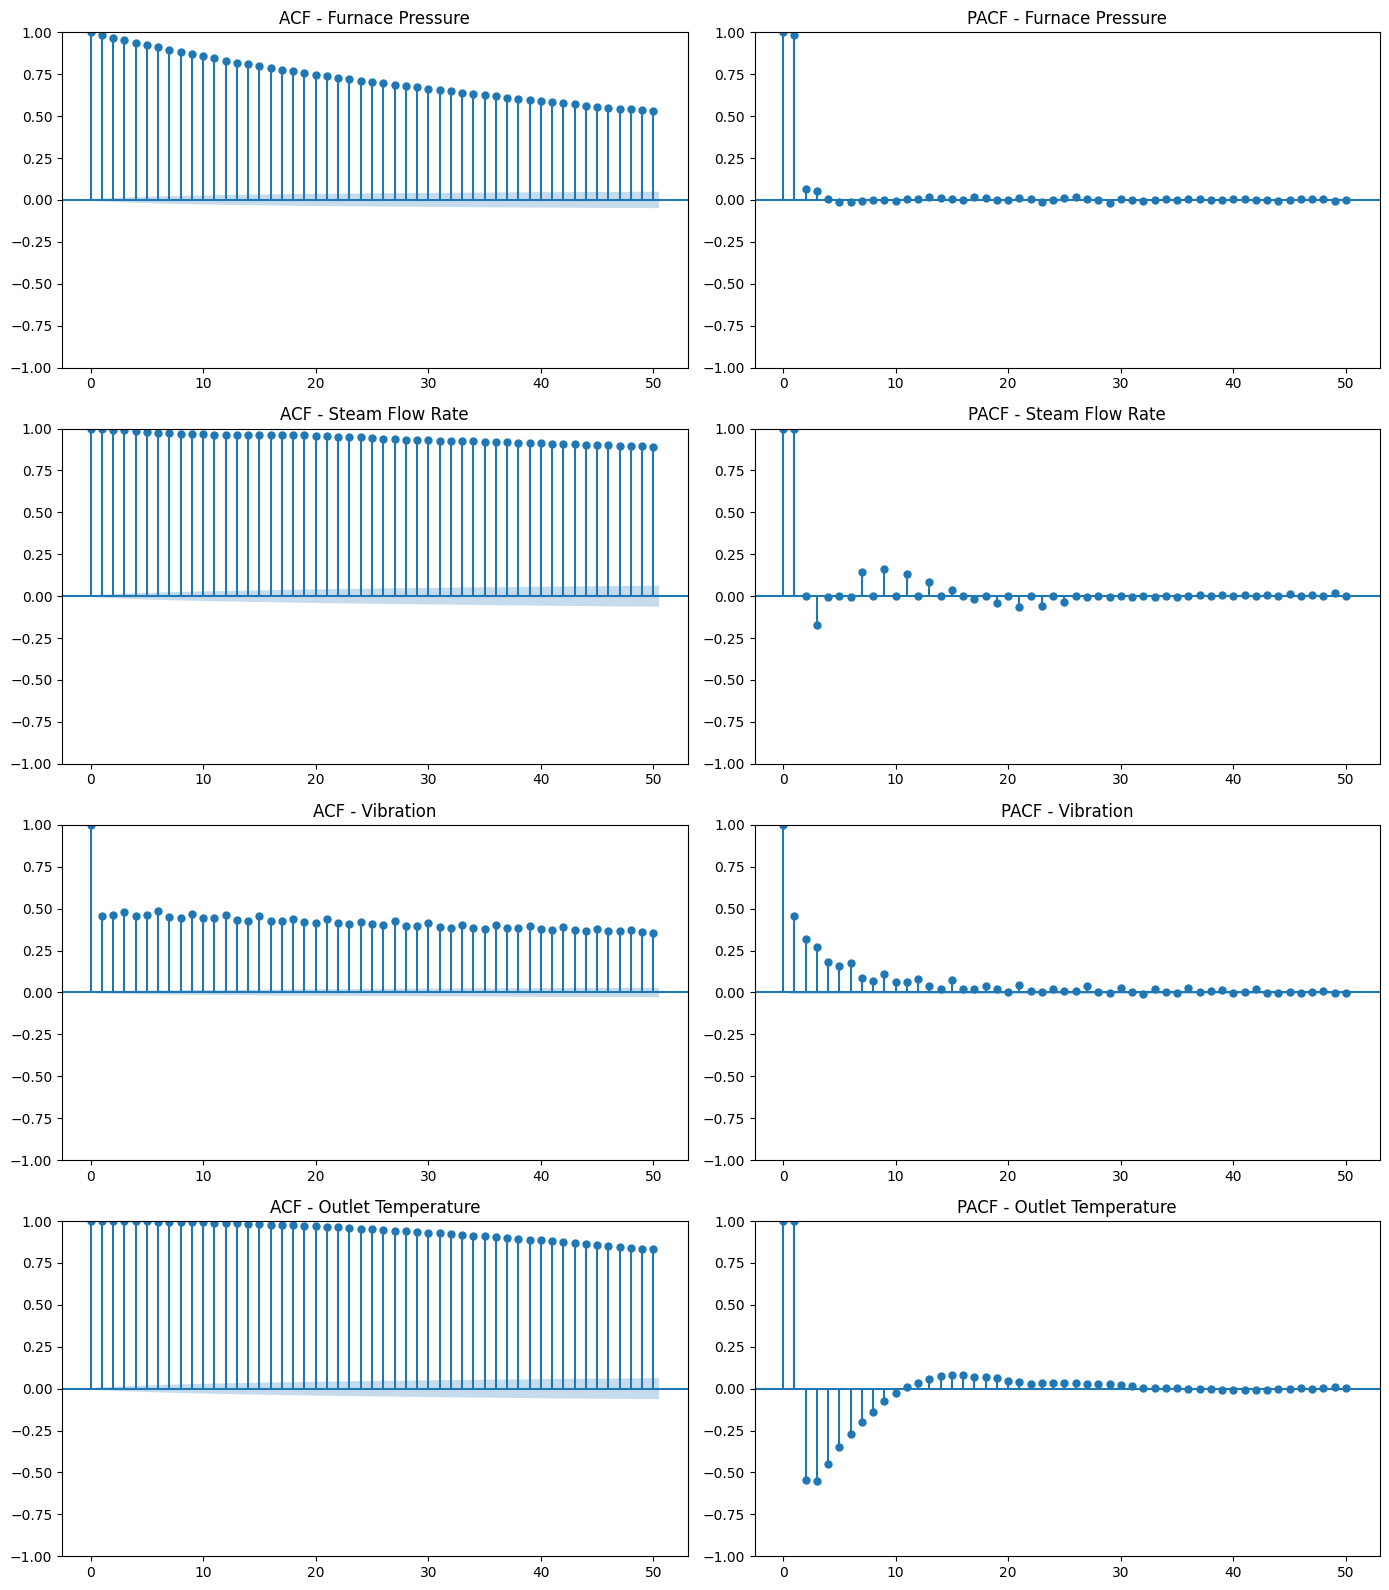

In [10]:
fig, axs = plt.subplots(4, 2, figsize=(14, 16))

series = [furnace_pressure, steam_flow_rate, vibration, outlet_temp]
titles = ['Furnace Pressure', 'Steam Flow Rate', 'Vibration', 'Outlet Temperature']

for i, s in enumerate(series):
    plot_acf(s.dropna(), lags=50, ax=axs[i, 0])
    axs[i, 0].set_title(f'ACF - {titles[i]}')
    
    plot_pacf(s.dropna(), lags=50, ax=axs[i, 1], method='ywm')
    axs[i, 1].set_title(f'PACF - {titles[i]}')

plt.tight_layout()
plt.show()

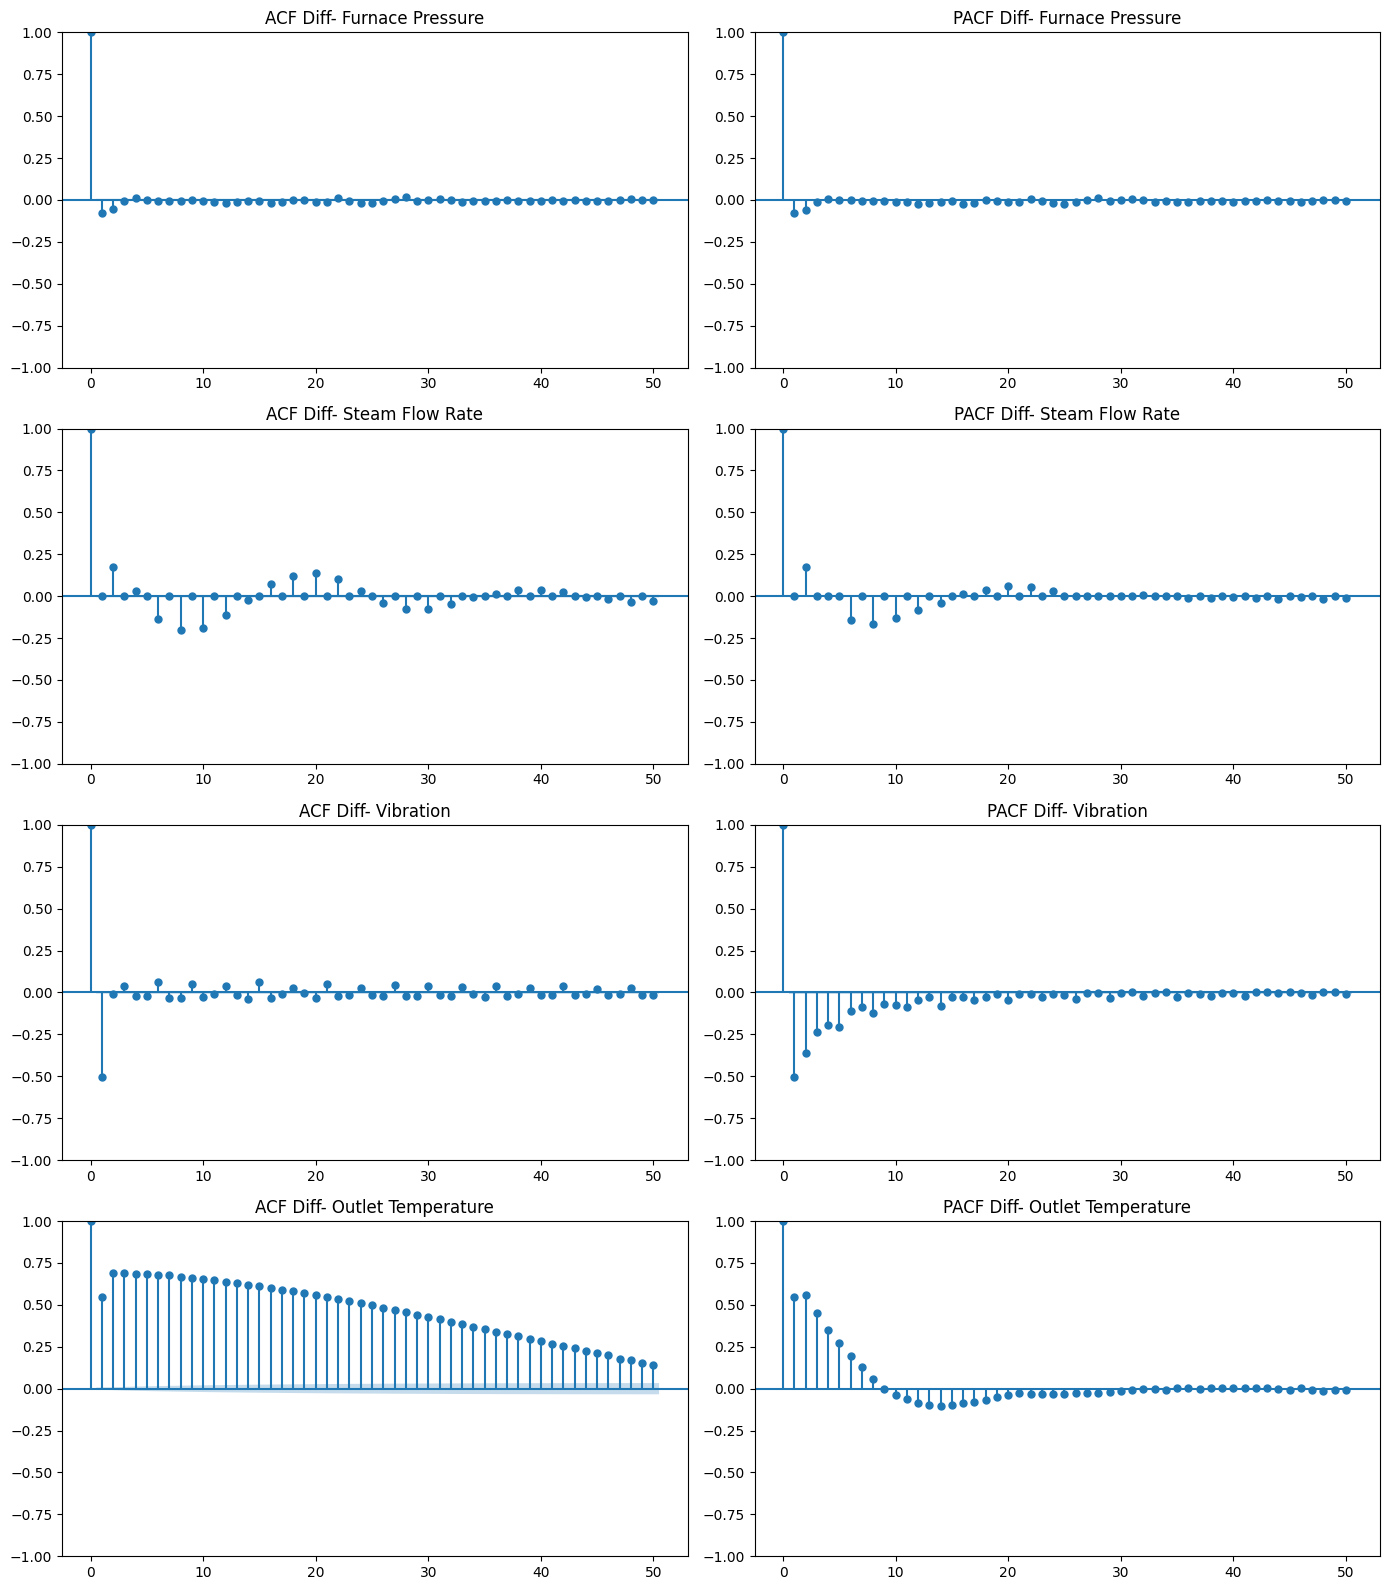

In [11]:
fig, axs = plt.subplots(4, 2, figsize=(14, 16))

series = [furnace_pressure, steam_flow_rate, vibration, outlet_temp]
titles = ['Furnace Pressure', 'Steam Flow Rate', 'Vibration', 'Outlet Temperature']

for i, s in enumerate(series):
    plot_acf(s.diff().dropna(), lags=50, ax=axs[i, 0])
    axs[i, 0].set_title(f'ACF Diff- {titles[i]}')
    
    plot_pacf(s.diff().dropna(), lags=50, ax=axs[i, 1], method='ywm')
    axs[i, 1].set_title(f'PACF Diff- {titles[i]}')

plt.tight_layout()
plt.show()

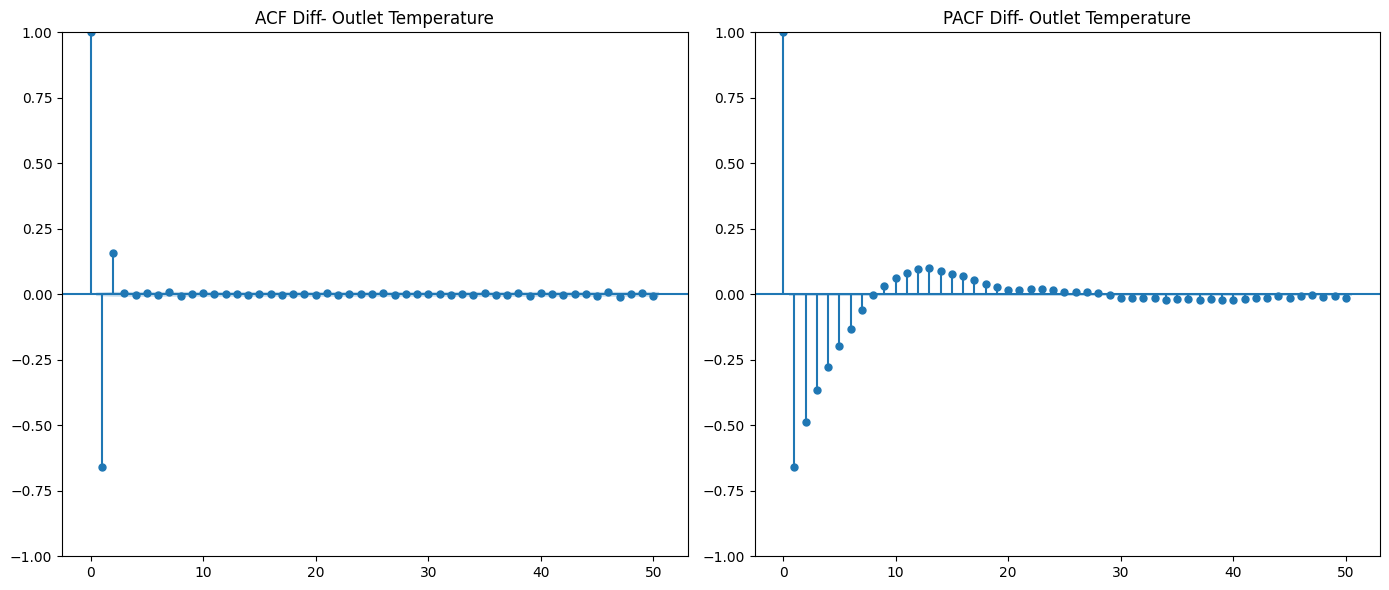

,Feature,Skewness,Kurtosis,ADF (original),KPSS (original),ADF (diff),KPSS (diff),d
0,Furnace Pressure,-0.606940,1.753128,0.000000e+00,0.01,0.0,0.1,1
1,Steam Flow Rate,-0.287475,0.724693,9.005895e-14,0.01,0.0,0.1,1
2,Vibration,0.173817,0.906210,1.998133e-26,0.01,0.0,0.1,1
3,Outlet Temperature,-0.246884,-0.042081,7.377972e-25,0.01,0.0,0.1,2


In [12]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))  

series = [outlet_temp]
titles = ['Outlet Temperature']

for i, s in enumerate(series):
    plot_acf(s.diff().diff().dropna(), lags=50, ax=axs[0])
    axs[0].set_title(f'ACF Diff- {titles[i]}')

    plot_pacf(s.diff().diff().dropna(), lags=50, ax=axs[1], method='ywm')
    axs[1].set_title(f'PACF Diff- {titles[i]}')

plt.tight_layout()
plt.show()


outlet_temp_diff2 = outlet_temp.diff().diff().dropna()
outlet_temp_diff_ADF = adfuller(outlet_temp_diff2)[1]
outlet_temp_diff_kpss = kpss(outlet_temp_diff2, regression='c')[1]

result_df['d'] = 1

result_df.loc[result_df['Feature'] == 'Outlet Temperature', 'd'] = 2

result_df.loc[result_df['Feature'] == 'Outlet Temperature', 'ADF (diff)'] = outlet_temp_diff_ADF
result_df.loc[result_df['Feature'] == 'Outlet Temperature', 'KPSS (diff)'] = outlet_temp_diff_kpss

result_df

In [13]:
result_df['p'] = 0
result_df['q'] = 0

result_df.loc[result_df['Feature'] == 'Furnace Pressure', 'p'] = 0
result_df.loc[result_df['Feature'] == 'Furnace Pressure', 'q'] = 3

result_df.loc[result_df['Feature'] == 'Steam Flow Rate', 'p'] = 0
result_df.loc[result_df['Feature'] == 'Steam Flow Rate', 'q'] = 3

result_df.loc[result_df['Feature'] == 'Vibration', 'p'] = 0
result_df.loc[result_df['Feature'] == 'Vibration', 'q'] = 15

result_df.loc[result_df['Feature'] == 'Outlet Temperature', 'p'] = 0
result_df.loc[result_df['Feature'] == 'Outlet Temperature', 'q'] = 10

## ARIMA Model 

The ARIMA model (AutoRegressive Integrated Moving Average) is a powerful tool for modeling and forecasting time series data. It combines three components:

- **AR (p):** AutoRegressive part, uses past values.
- **I (d):** Integration order, number of differences needed for stationarity.
- **MA (q):** Moving Average part, uses past forecast errors.

Our previous ACF/PACF analysis and stationarity tests guided us in selecting appropriate orders for each feature.

---

### Setting ARIMA Orders (p, d, q)

From the ACF and PACF plots and stationarity checks, we assign the following orders:

| Feature            | p (AR order) | d (Differencing order) | q (MA order) |
|--------------------|--------------|-----------------------|--------------|
| Furnace Pressure   | 0            | 1                     | 3            |
| Steam Flow Rate    | 0            | 1                     | 3            |
| Vibration         | 0            | 1                     | 15           |
| Outlet Temperature | 0            | 2                     | 10           |

- Differencing order `d` reflects the number of differences applied for stationarity.
- `p` and `q` come from inspecting PACF (AR) and ACF (MA) plots, respectively.

---


### Explanation and Interpretation
Order parameters:

- We use the differenced data (d times differenced) as input to the model fitting.

- p=0 indicates no AR terms; the PACF suggested no significant autoregressive lags.

- q values correspond to the number of MA terms, matching the number of significant spikes in ACF.

### Model summary output:

Displays estimated parameters (coefficients) of the MA terms.

- Provides goodness-of-fit metrics such as AIC, BIC for model comparison.

- Includes diagnostics like residual analysis to check model adequacy.

In [14]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(outlet_temp.diff().diff().dropna(), order=(10, 2, 0))
result = model.fit()
print(result.summary())

model = ARIMA(steam_flow_rate.diff().dropna(), order=(3, 1, 0))
result = model.fit()
print(result.summary())

model = ARIMA(vibration.diff().dropna(), order=(15, 1, 0))
result = model.fit()
print(result.summary())

model = ARIMA(furnace_pressure.diff().dropna(), order=(3, 1, 0))
result = model.fit()
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:         TE_8332A.AV_0#   No. Observations:                86398
Model:                ARIMA(10, 2, 0)   Log Likelihood              142406.415
Date:                Fri, 06 Jun 2025   AIC                        -284790.831
Time:                        14:41:19   BIC                        -284687.797
Sample:                    03-27-2022   HQIC                       -284759.356
                         - 04-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -2.8122      0.003   -854.471      0.000      -2.819      -2.806
ar.L2         -4.8046      0.010   -504.631      0.000      -4.823      -4.786
ar.L3         -6.3371      0.017   -367.966      0.0

### Interpretation of Your ARIMA Model Summaries

#### 1. **Outlet Temperature — ARIMA(10, 2, 0)**

* **Model:** AR(10), differenced twice, no MA terms.
* **Coefficients:** All AR lags highly significant (`p < 0.001`) with large negative values.
* **Diagnostics:**

  * Ljung-Box Q test significant at lag 1 (Q=405.54, p=0.00) → some residual autocorrelation remains, model may not capture all dependencies.
  * Jarque-Bera test indicates residuals are normally distributed (`p=0.53`).
  * Heteroskedasticity test non-significant (`p=0.38`), variance is stable.
* **Implication:** Model fits well overall but could be improved to address residual autocorrelation.

---

#### 2. **Steam Flow Rate — ARIMA(3, 1, 0)**

* **Model:** AR(3), differenced once, no MA terms.
* **Coefficients:** All AR terms highly significant.
* **Diagnostics:**

  * Ljung-Box Q test significant (Q=108.30, p=0.00), suggesting residual autocorrelation.
  * Jarque-Bera test highly significant (p=0.00), residuals are not normally distributed (heavy tails or skewness).
  * Some heteroskedasticity detected (p=0.00).
* **Implication:** Residuals exhibit non-normality and dependence — consider adding MA terms or using GARCH models for volatility clustering.

---

#### 3. **Vibration — ARIMA(15, 1, 0)**

* **Model:** AR(15), differenced once, no MA terms.
* **Coefficients:** All AR coefficients significant.
* **Diagnostics:**

  * Ljung-Box Q test significant (Q=10.46, p=0.00), residual autocorrelation persists.
  * Jarque-Bera test highly significant (p=0.00), non-normal residuals.
  * Heteroskedasticity present (p=0.00).
* **Implication:** High-order AR model fits the data, but residual issues remain; further model refinement is needed.

---

#### 4. **Furnace Pressure — ARIMA(3, 1, 0)**

* **Model:** AR(3), differenced once, no MA terms.
* **Coefficients:** All significant.
* **Diagnostics:**

  * Ljung-Box Q test significant (Q=337.11, p=0.00), residual autocorrelation.
  * Jarque-Bera extremely significant (p=0.00), strong non-normality (heavy kurtosis).
  * Some heteroskedasticity detected (p=0.03).
* **Implication:** Simple AR model insufficient; model could be improved by including MA terms or advanced models (e.g., SARIMA, GARCH).

---


In [15]:
import pmdarima as pm

model = pm.auto_arima(outlet_temp.diff().diff().dropna(), d=2, seasonal=False, stepwise=True, trace=True)
print(model.summary())

model = pm.auto_arima(steam_flow_rate.diff().dropna(), d=1, seasonal=False, stepwise=True, trace=True)
print(model.summary())

model = pm.auto_arima(vibration.diff().dropna(), d=1, seasonal=False, stepwise=True, trace=True)
print(model.summary())

model = pm.auto_arima(furnace_pressure.diff().dropna(), d=1, seasonal=False, stepwise=True, trace=True)
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=-274949.484, Time=139.67 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=-19820.628, Time=9.87 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=-107166.853, Time=4.76 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=57.65 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=-19822.628, Time=2.50 sec
 ARIMA(1,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=109.68 sec
 ARIMA(2,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=71.16 sec
 ARIMA(3,2,2)(0,0,0)[0] intercept   : AIC=-240382.403, Time=117.58 sec
 ARIMA(2,2,3)(0,0,0)[0] intercept   : AIC=inf, Time=128.00 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=-189707.000, Time=44.52 sec
 ARIMA(1,2,3)(0,0,0)[0] intercept   : AIC=inf, Time=169.32 sec
 ARIMA(3,2,1)(0,0,0)[0] intercept   : AIC=-250542.578, Time=123.12 sec
 ARIMA(3,2,3)(0,0,0)[0] intercept   : AIC=inf, Time=206.79 sec
 ARIMA(2,2,2)(0,0,0)[0]             : AIC=inf, Time=67.24 sec

Best model:  ARIMA(2,2,2)(0,0,